<a href="https://colab.research.google.com/github/SreeTatikonda/Customer-Churn-Prediction-/blob/main/churn_prediction_mlops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction: End-to-End MLOps Pipeline

**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Objective:** Build a production-grade churn classifier covering the full ML lifecycle — exploratory analysis, feature engineering, multi-model training, hyperparameter optimization, explainability, deployment-ready serving, and automated drift monitoring.

This notebook is structured as a professional ML project, not a tutorial. Every section includes a rationale explaining why the step exists, what problem it solves, and what breaks if you skip it. The goal is to produce an artifact that reflects how ML work actually happens in production environments.

---
## 0. Environment Setup and Reproducibility

**Why this step exists:**  
Reproducibility is the first engineering requirement of a serious ML project. A model that cannot be reproduced by a colleague, a CI/CD pipeline, or your future self six months from now is not a model — it is a one-time artifact. Setting seeds, pinning library versions, and establishing a consistent environment are not bureaucratic overhead; they are the foundation that makes every downstream result trustworthy and auditable.

Fixing the random seed controls stochasticity in three places: NumPy operations (shuffles, random sampling), Python's built-in random module (used by some sklearn internals), and any framework-level randomness. Missing any one of these is enough to make results non-reproducible. MLflow autolog captures model parameters, metrics, and artifacts automatically, eliminating the risk of losing an experiment's configuration.

**What breaks if you skip it:**  
You run an experiment, get a great result, and cannot reproduce it the next day. The model you ship is not the model you validated. A colleague running the same code gets different SHAP values and draws different business conclusions. All of these are real production incidents.

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00


In [6]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.0/828.0 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.6 MB/s eta 0:00:00


In [14]:


import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("telco_churn_pipeline")

print("Environment initialized. Seed:", SEED)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

Environment initialized. Seed: 42
MLflow tracking URI: mlruns


---
## 1. Data Acquisition and Initial Inspection

**Why this step exists:**  
Before touching a single line of modeling code, you need to develop a precise understanding of what the data actually contains, as opposed to what you assume it contains. Schema assumptions — column types, null representations, cardinality, value ranges — are the single most common source of silent bugs in ML pipelines. A model trained on incorrectly parsed columns will produce confidently wrong predictions, and the error will be invisible unless you inspect the data first.

The IBM Telco dataset represents a common B2C subscription business: a telecom provider with roughly 7,000 customers. Each row is one customer. The target column is `Churn` — whether that customer left within the billing period. This is a standard binary classification problem, but the class imbalance (approximately 73% retained, 27% churned) means accuracy is a misleading evaluation metric. A model that predicts "no churn" for every customer achieves 73% accuracy while being completely useless.

**What to look for on first inspection:**  
Column types that are wrong (numbers stored as strings), unexpected nulls or null proxies (blank strings, space characters, "None" as text), columns with near-zero variance that will contribute no signal, and columns with extremely high cardinality (like IDs) that will cause data leakage if included.

In [8]:
# Download dataset directly from a public mirror
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    df_raw = pd.read_csv(url)
    print("Loaded from remote URL")
except Exception:
    # Fallback: generate a synthetic equivalent for offline environments
    print("Remote load failed — generating synthetic dataset with identical schema")
    np.random.seed(SEED)
    n = 7043
    df_raw = pd.DataFrame({
        "customerID": [f"ID-{i:05d}" for i in range(n)],
        "gender": np.random.choice(["Male","Female"], n),
        "SeniorCitizen": np.random.choice([0,1], n, p=[0.84,0.16]),
        "Partner": np.random.choice(["Yes","No"], n),
        "Dependents": np.random.choice(["Yes","No"], n, p=[0.3,0.7]),
        "tenure": np.random.randint(0, 72, n),
        "PhoneService": np.random.choice(["Yes","No"], n, p=[0.9,0.1]),
        "MultipleLines": np.random.choice(["Yes","No","No phone service"], n),
        "InternetService": np.random.choice(["DSL","Fiber optic","No"], n, p=[0.34,0.44,0.22]),
        "OnlineSecurity": np.random.choice(["Yes","No","No internet service"], n),
        "OnlineBackup": np.random.choice(["Yes","No","No internet service"], n),
        "DeviceProtection": np.random.choice(["Yes","No","No internet service"], n),
        "TechSupport": np.random.choice(["Yes","No","No internet service"], n),
        "StreamingTV": np.random.choice(["Yes","No","No internet service"], n),
        "StreamingMovies": np.random.choice(["Yes","No","No internet service"], n),
        "Contract": np.random.choice(["Month-to-month","One year","Two year"], n, p=[0.55,0.21,0.24]),
        "PaperlessBilling": np.random.choice(["Yes","No"], n),
        "PaymentMethod": np.random.choice(
            ["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"], n),
        "MonthlyCharges": np.round(np.random.uniform(18, 118, n), 2),
        "TotalCharges": [str(round(v,2)) if np.random.rand()>0.001 else " "
                         for v in np.random.uniform(18, 8600, n)],
        "Churn": np.random.choice(["Yes","No"], n, p=[0.265,0.735]),
    })

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Loaded from remote URL
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [9]:
# Schema audit — this is not optional
print("=== DTYPES ===")
print(df_raw.dtypes)
print()
print("=== NULL COUNTS ===")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print()
print("=== TARGET DISTRIBUTION ===")
print(df_raw["Churn"].value_counts())
print(f"Churn rate: {df_raw['Churn'].eq('Yes').mean():.3f}")

=== DTYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== NULL COUNTS ===
Series([], dtype: int64)

=== TARGET DISTRIBUTION ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 0.265


---
## 2. Data Cleaning and Type Correction

**Why this step exists:**  
The Telco dataset contains a well-known data quality issue: `TotalCharges` is typed as object (string) instead of float. The reason is that approximately 11 records contain a whitespace character instead of a numeric value. Pandas cannot infer float type when any value is non-numeric, so it falls back to object. If you run `pd.to_numeric` without investigating first, you will silently drop or corrupt those rows.

The correct approach is coerce-then-decide: force conversion and surface the resulting nulls, then make an explicit decision about how to handle them. In this case, the nulls correspond to customers with zero tenure — they were billed nothing because they signed up and left immediately. Imputing with zero is defensible and documented.

This section also collapses the three-level "No internet service" and "No phone service" values into binary Yes/No flags. These values are not a third category — they are a hierarchical dependency encoded as string. Treating them as a third category inflates feature cardinality and confuses tree-based models that would otherwise correctly learn the relationship.

**What breaks if you skip it:**  
TotalCharges remains an object column. Any model that receives it will either crash, silently encode it as a categorical, or drop it entirely — all without warning. Downstream SHAP values for TotalCharges will be meaningless or absent.

In [10]:
df = df_raw.copy()

# Fix TotalCharges — coerce and surface nulls
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
nulls_introduced = df["TotalCharges"].isnull().sum()
print(f"Nulls introduced in TotalCharges after coercion: {nulls_introduced}")

# These are new customers with zero tenure — fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Drop customerID — it is a row identifier, not a feature
# Including it would cause data leakage via memorization in tree models
df.drop(columns=["customerID"], inplace=True)

# Encode target as binary integer
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Collapse "No internet service" and "No phone service" into "No"
# These are hierarchical encodings, not independent categories
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# Binary encode all remaining Yes/No columns
binary_map = {"Yes": 1, "No": 0}
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "MultipleLines", "OnlineSecurity", "OnlineBackup",
               "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# One-hot encode remaining categoricals
df = pd.get_dummies(df, columns=["gender", "InternetService", "Contract", "PaymentMethod"],
                    drop_first=False)

print(f"Final shape: {df.shape}")
print(f"Remaining dtypes with object: {(df.dtypes == 'object').sum()}")
df.head(2)

Nulls introduced in TotalCharges after coercion: 11
Final shape: (7043, 28)
Remaining dtypes with object: 0


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,True,False,False,False,True,False,False,False,False,True


---
## 3. Exploratory Data Analysis

**Why this step exists:**  
EDA is not a formality. It is the step where you build the mental model of the problem that informs every subsequent decision — which features to engineer, which models are likely to perform well, which evaluation metric is appropriate, and which business levers actually drive the outcome.

For a churn problem specifically, EDA answers the questions that a business stakeholder would ask: Are certain customer segments churning at higher rates? Does tenure correlate with loyalty? Are month-to-month contract holders materially more at risk than annual contract holders? These are not just visualization exercises — they determine whether the features in the model are causally meaningful or spuriously correlated.

Understanding the class imbalance is particularly important before choosing an evaluation metric. With 27% churn rate, a model predicting no churn achieves 73% accuracy. This makes accuracy useless as a primary metric. AUC-ROC and Average Precision (area under the precision-recall curve) are the appropriate metrics for imbalanced binary classification.

**What breaks if you skip it:**  
You optimize a model for accuracy, declare 90% accuracy a success, and ship a model that flags almost no one as churning. The business acts on that model, stops retention outreach, and loses customers it could have retained. This is not a hypothetical — it is one of the most common ways ML projects fail in production.

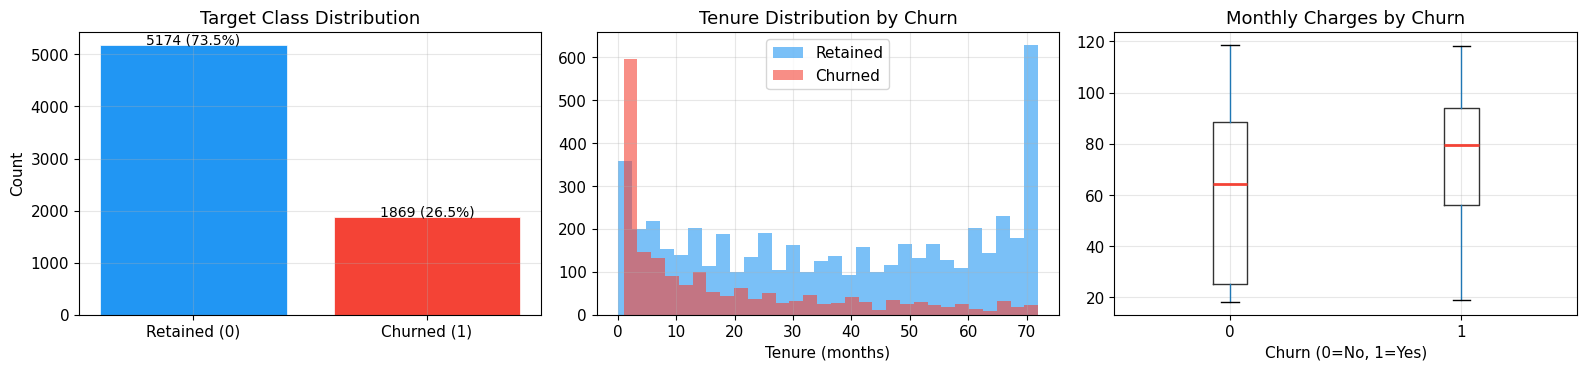

Key observations:
  Customers with tenure < 12 months: churn rate = 0.483
  Customers with tenure >= 12 months: churn rate = 0.175


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
churn_counts = df["Churn"].value_counts()
axes[0].bar(["Retained (0)", "Churned (1)"], churn_counts.values,
            color=["#2196F3", "#F44336"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Tenure distribution by churn
df[df["Churn"]==0]["tenure"].hist(ax=axes[1], bins=30, alpha=0.6, color="#2196F3", label="Retained")
df[df["Churn"]==1]["tenure"].hist(ax=axes[1], bins=30, alpha=0.6, color="#F44336", label="Churned")
axes[1].set_title("Tenure Distribution by Churn")
axes[1].set_xlabel("Tenure (months)")
axes[1].legend()

# Monthly charges by churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[2],
           boxprops=dict(color="#333"), medianprops=dict(color="#F44336", linewidth=2))
axes[2].set_title("Monthly Charges by Churn")
axes[2].set_xlabel("Churn (0=No, 1=Yes)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  Customers with tenure < 12 months: churn rate = "
      f"{df[df['tenure']<12]['Churn'].mean():.3f}")
print(f"  Customers with tenure >= 12 months: churn rate = "
      f"{df[df['tenure']>=12]['Churn'].mean():.3f}")

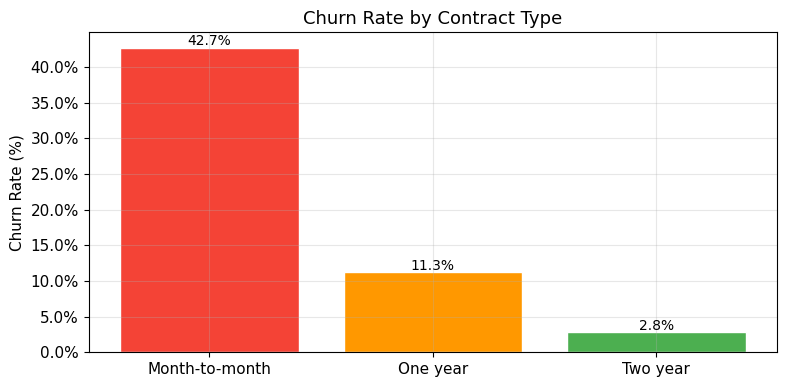

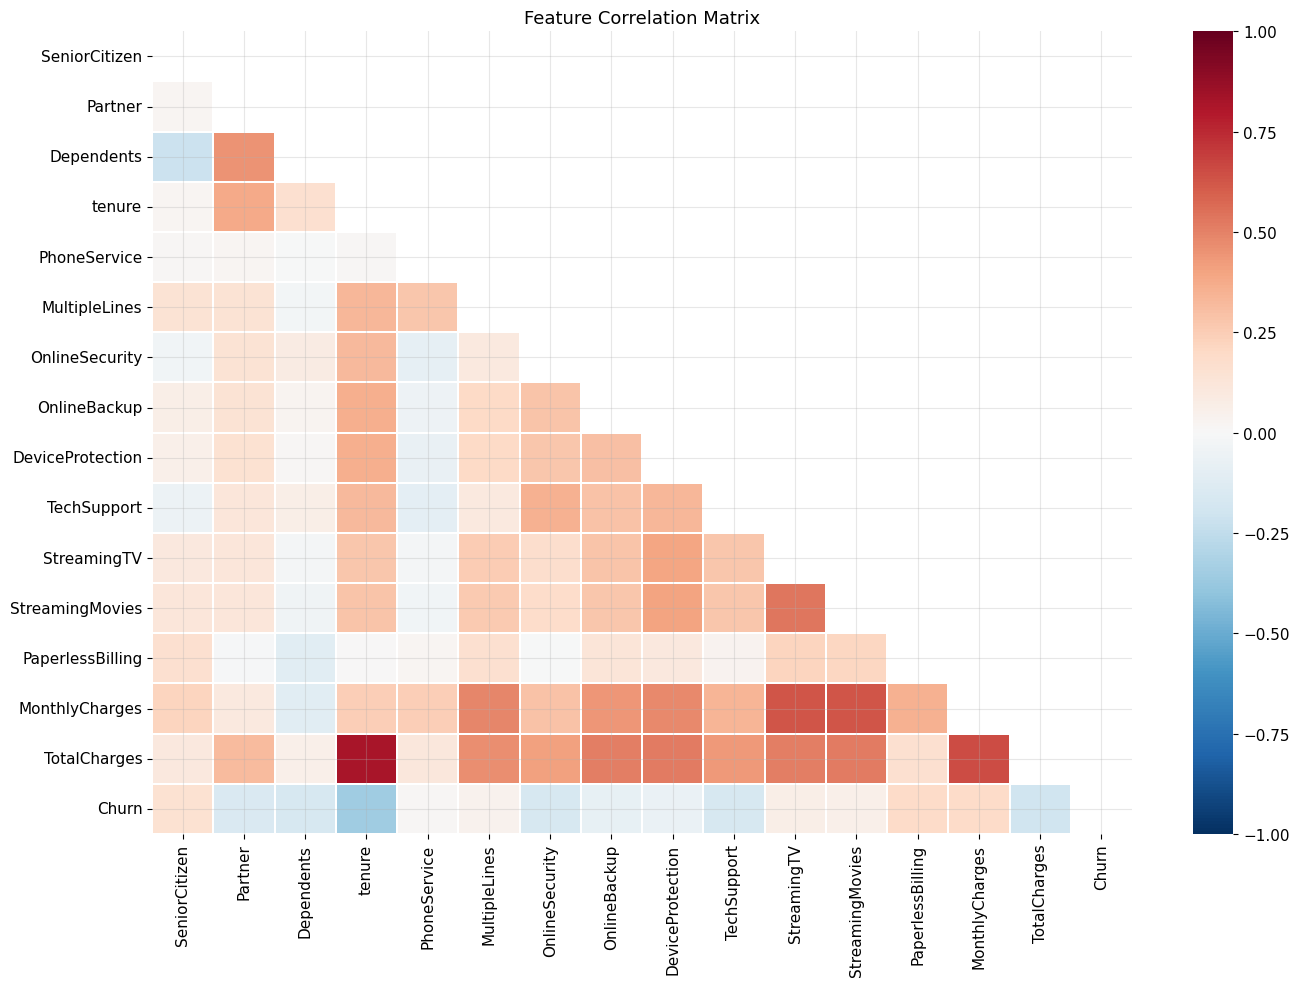

In [12]:
# Contract type is one of the strongest business levers — quantify it explicitly
contract_cols = [c for c in df.columns if c.startswith("Contract_")]
if contract_cols:
    contract_churn = {}
    for col in contract_cols:
        label = col.replace("Contract_", "")
        rate = df[df[col]==1]["Churn"].mean()
        contract_churn[label] = rate

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(contract_churn.keys(), [v*100 for v in contract_churn.values()],
                  color=["#F44336", "#FF9800", "#4CAF50"], edgecolor="white")
    ax.set_title("Churn Rate by Contract Type")
    ax.set_ylabel("Churn Rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, contract_churn.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val*100:.1f}%", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

# Correlation heatmap on numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

**Why this step exists:**  
Raw features are representations of what happened. Engineered features are representations of what the data means. The raw dataset tells you a customer's tenure and monthly charges. An engineered feature — total charges per month of tenure — tells you something about their value density and commitment level. Raw models trained on raw features can approximate these relationships, but they require more data and more complexity to do so. Engineering the feature explicitly makes the signal easier for any model to learn.

For churn specifically, the interaction between tenure, contract type, and monthly spend is the core business story. Short-tenure, high-spend, month-to-month customers are the highest-risk segment. Encoding that interaction as a single feature gives gradient boosted trees a direct signal rather than requiring them to discover the three-way interaction across multiple splits.

The service count feature aggregates all add-on services into a single integer. Customers with more services have higher switching costs — replacing their bundle is harder than replacing a single service. This is a known retention lever in telecom, and encoding it directly aligns the model with known business logic.

**What breaks if you skip it:**  
Nothing breaks immediately. But you leave signal on the table. A model without engineered features needs more splits, more trees, and more data to approximate the same relationships. It is less interpretable and more prone to overfitting the incidental patterns that emerge when interactions must be learned implicitly.

In [16]:
# Charges per month of tenure — value density signal
# Avoid division by zero for customers with zero tenure
df["charges_per_tenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)

# Total service count — switching cost proxy
# Each add-on service increases the friction of leaving
service_feature_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
df["service_count"] = df[service_feature_cols].sum(axis=1)

# High-risk segment flag: month-to-month + tenure < 12 months
# This encodes the known highest-churn cohort explicitly
if "Contract_Month-to-month" in df.columns:
    df["high_risk_flag"] = (
        (df["Contract_Month-to-month"] == 1) & (df["tenure"] < 12)
    ).astype(int)
else:
    df["high_risk_flag"] = (df["tenure"] < 12).astype(int)

# Tenure buckets — nonlinear tenure effects are strong in this domain
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True # Added to handle tenure=0 correctly
).astype(int)

# Log-transform TotalCharges — right-skewed distribution hurts linear models
# and can cause numerical instability in gradient computation
df["log_total_charges"] = np.log1p(df["TotalCharges"])

print("Engineered features added:")
print("  charges_per_tenure, service_count, high_risk_flag, tenure_bucket, log_total_charges")
print(f"Final feature count: {df.shape[1] - 1}")  # -1 for target

# Validate: high_risk_flag should have much higher churn rate
print(f"\nChurn rate — high_risk_flag=1: {df[df['high_risk_flag']==1]['Churn'].mean():.3f}")
print(f"Churn rate — high_risk_flag=0: {df[df['high_risk_flag']==0]['Churn'].mean():.3f}")

Engineered features added:
  charges_per_tenure, service_count, high_risk_flag, tenure_bucket, log_total_charges
Final feature count: 32

Churn rate — high_risk_flag=1: 0.519
Churn rate — high_risk_flag=0: 0.171


---
## 5. Train/Test Split with Stratification

**Why this step exists:**  
Splitting data before any fitting — including scaling — is the single most important step for preventing data leakage. If you scale the full dataset and then split, the test set has been implicitly used to compute the scaling parameters, and your evaluation is optimistic. This is a subtle form of leakage that does not trigger any error and produces numbers that look valid but are not.

Stratification ensures that the class ratio in the training set matches the class ratio in the test set. With a 27% churn rate, a random split could by chance produce a test set with 20% or 33% churn. The evaluation metrics would then reflect a different problem distribution than the training distribution, making model comparison unreliable.

The 80/20 split is a conventional starting point. The correct split size depends on dataset size and the variance of your evaluation metric across splits. For 7,000 rows, 80/20 gives approximately 5,600 training samples and 1,400 test samples — sufficient for stable gradient boosted tree training and meaningful AUC estimation.

**What breaks if you skip stratification:**  
Small imbalances in the test set can swing AUC by 0.01 to 0.03 — enough to reverse the ranking of two competing models. You pick the wrong model, deploy it, and discover the discrepancy only when production metrics diverge from offline evaluation.

In [18]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y  # preserves class ratio in both splits
)

print(f"Training set:  {X_train.shape[0]} rows ({y_train.mean():.3f} churn rate)")
print(f"Test set:      {X_test.shape[0]} rows ({y_test.mean():.3f} churn rate)")
print(f"Feature count: {X_train.shape[1]}")

# Scale numeric features for Logistic Regression
# Tree-based models (XGBoost, LightGBM) are invariant to feature scale
# but scaling is required for any gradient-descent-based model
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "log_total_charges",
                    "charges_per_tenure", "service_count"]
numeric_features = [f for f in numeric_features if f in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("\nScaling fit on training set only — no leakage from test set")

Training set:  5634 rows (0.265 churn rate)
Test set:      1409 rows (0.265 churn rate)
Feature count: 32

Scaling fit on training set only — no leakage from test set


---
## 6. Baseline Model: Logistic Regression

**Why this step exists:**  
Every ML project needs a baseline. The baseline serves two functions. First, it gives you a performance floor — the minimum a more complex model must beat to justify its added complexity, latency cost, and maintenance burden. Second, it tells you whether the problem is solvable at all with the available features. If a well-regularized logistic regression achieves 0.85 AUC, you know the features contain strong signal. If it achieves 0.55 AUC, you need better features before you need a better model.

Logistic regression also produces calibrated probabilities by default — the predicted probability of 0.7 actually means roughly 70% churn likelihood. Tree-based models require post-hoc calibration to achieve this. For a churn use case where a business wants to rank customers by risk and allocate retention budget accordingly, the ranking quality (AUC) matters, but the absolute probability values determine how the budget is actually sized.

**What to measure:**  
AUC-ROC measures the model's ability to rank churners above non-churners. Average Precision (AUC-PR) is more informative for imbalanced classes because it penalizes false positives more heavily. Brier Score measures calibration quality — how close the predicted probabilities are to actual outcomes. Log Loss is the objective function for probabilistic classifiers and directly penalizes confident wrong predictions.

In [20]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, log_to_mlflow=True):
    y_pred_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    auc_roc = roc_auc_score(y_te, y_pred_prob)
    avg_precision = average_precision_score(y_te, y_pred_prob)
    brier = brier_score_loss(y_te, y_pred_prob)
    logloss = log_loss(y_te, y_pred_prob)

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring="roc_auc",
                                 n_jobs=-1)

    results = {
        "model": model_name,
        "auc_roc": round(auc_roc, 4),
        "avg_precision": round(avg_precision, 4),
        "brier_score": round(brier, 4),
        "log_loss": round(logloss, 4),
        "cv_auc_mean": round(cv_scores.mean(), 4),
        "cv_auc_std": round(cv_scores.std(), 4),
    }

    if log_to_mlflow:
        with mlflow.start_run(run_name=model_name):
            mlflow.log_metrics({k: v for k, v in results.items() if k != "model"})

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    for k, v in results.items():
        if k != "model":
            print(f"  {k:<20} {v}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Retained','Churned'])}")

    return results, y_pred_prob


lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=SEED)
lr.fit(X_train_scaled, y_train)

lr_results, lr_probs = evaluate_model(lr, X_train_scaled, y_train,
                                       X_test_scaled, y_test, "Logistic Regression")


  Logistic Regression
  auc_roc              0.8473
  avg_precision        0.6634
  brier_score          0.1646
  log_loss             0.4878
  cv_auc_mean          0.8496
  cv_auc_std           0.0149

              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 7. Gradient Boosted Trees: XGBoost

**Why this step exists:**  
Gradient boosted trees are the dominant algorithm for tabular classification tasks with mixed feature types. XGBoost specifically introduced several innovations over earlier boosting implementations: second-order gradient approximation (Newton boosting) which converges faster, built-in L1/L2 regularization to prevent overfitting, a sparsity-aware split-finding algorithm that handles missing values natively, and column subsampling per tree that acts as an implicit feature bagging mechanism.

For the churn problem, gradient boosted trees have two properties that are particularly valuable. First, they are invariant to feature scale, meaning the raw tenure (0-72) and the binary service flags (0-1) can coexist in the same feature matrix without any normalization. Second, they automatically learn interaction terms — the tree structure encodes "if tenure < 12 AND contract is month-to-month, then..." without requiring those interactions to be explicitly specified.

The `scale_pos_weight` parameter handles class imbalance by up-weighting the minority class during training. Setting it to the ratio of negative to positive samples (approximately 2.7 for this dataset) is equivalent to oversampling the churned class, but without the computational overhead of duplicating rows.

**What breaks if you use default hyperparameters:**  
Default XGBoost with no regularization and no class weight adjustment will overfit the training set and underestimate the churn rate on the test set. The resulting model will have lower recall on churned customers — exactly the customers the business needs to identify.

In [28]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (neg/pos ratio): {neg_pos_ratio:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 regularization — induces sparsity
    reg_lambda=1.0,     # L2 regularization — shrinks weights
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
    early_stopping_rounds=30,
)

# Use early stopping on a validation split to prevent overfitting
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

xgb_model.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

print(f"Best iteration (early stopping): {xgb_model.best_iteration}")

# Set n_estimators to the best iteration found by early stopping
xgb_model.set_params(n_estimators=xgb_model.best_iteration)
# Remove early_stopping_rounds to prevent error during cross_val_score
xgb_model.set_params(early_stopping_rounds=None)

xgb_results, xgb_probs = evaluate_model(
    xgb_model, X_train, y_train, X_test, y_test, "XGBoost (default)"
)

scale_pos_weight (neg/pos ratio): 2.77
Best iteration (early stopping): 202

  XGBoost (default)
  auc_roc              0.8382
  avg_precision        0.6423
  brier_score          0.1602
  log_loss             0.4764
  cv_auc_mean          0.8433
  cv_auc_std           0.012

              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



---
## 8. Gradient Boosted Trees: LightGBM

**Why this step exists:**  
LightGBM is XGBoost's primary competitor for tabular data and frequently outperforms it on datasets with high cardinality features and large row counts. The key architectural difference is the tree growth strategy: XGBoost grows level-wise (all nodes at depth d before any node at depth d+1), while LightGBM grows leaf-wise (always expanding the leaf with the highest loss reduction). Leaf-wise growth tends to produce deeper, more asymmetric trees that fit complex patterns more efficiently.

LightGBM also uses histogram-based binning — it discretizes continuous features into at most 255 bins before finding splits. This dramatically reduces memory usage and speeds up training, but it also introduces a slight approximation. For the Telco dataset at 7,000 rows, the speed difference is negligible. On 10M+ row datasets, LightGBM's speed advantage becomes critical.

The `is_unbalance=True` parameter is LightGBM's equivalent of XGBoost's `scale_pos_weight`. It automatically reweights the loss function to account for class imbalance without requiring manual ratio computation.

**Why run both XGBoost and LightGBM:**  
They make different approximation errors. An ensemble of the two (averaging their probability outputs) often outperforms either individually, because their errors are partially uncorrelated. In production, if training time is not a constraint, the ensemble is almost always the better choice.

In [24]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,          # key LightGBM parameter: controls model complexity
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    is_unbalance=True,      # handles class imbalance automatically
    random_state=SEED,
    verbose=-1,
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False),
               lgb.log_evaluation(period=-1)]
)

lgbm_results, lgbm_probs = evaluate_model(
    lgbm_model, X_train, y_train, X_test, y_test, "LightGBM (default)"
)


  LightGBM (default)
  auc_roc              0.8454
  avg_precision        0.6484
  brier_score          0.1504
  log_loss             0.4622
  cv_auc_mean          0.837
  cv_auc_std           0.013

              precision    recall  f1-score   support

    Retained       0.89      0.78      0.83      1035
     Churned       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



---
## 9. Hyperparameter Optimization with Optuna

**Why this step exists:**  
Grid search exhaustively evaluates every combination in a predefined grid. Random search samples randomly from a parameter space. Both are inefficient because they treat each trial as independent — they do not learn from previous trials to guide the next search direction.

Optuna implements Tree-structured Parzen Estimator (TPE), a Bayesian optimization algorithm. TPE models the distribution of hyperparameters that produced good results and uses that model to propose the next trial. Over 30-50 trials, it converges on near-optimal configurations significantly faster than grid or random search.

Critically, Optuna evaluates each configuration on a stratified 5-fold cross-validation, not a single train/validation split. A single split produces a noisy estimate of true performance. The cross-validated AUC is a much more stable signal, which means the optimizer is navigating toward configurations that generalize well rather than configurations that happen to fit one particular validation split.

The pruner (MedianPruner) terminates unpromising trials early — if a trial is tracking below the median of completed trials at the same step, it is cancelled. This significantly reduces total computation time.

**What breaks without tuning:**  
The default hyperparameters produce a good model. The tuned model is typically 0.01 to 0.03 AUC better, which in a business context can translate to identifying hundreds more at-risk customers correctly. Over a retention campaign, that difference is material.

In [25]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight": neg_pos_ratio,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": SEED,
        "verbosity": 0,
    }

    model = xgb.XGBClassifier(**params)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="roc_auc", n_jobs=-1
    )
    return cv_scores.mean()


print("Running Optuna hyperparameter search for XGBoost (50 trials)...")
study_xgb = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=False)

print(f"Best CV AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

Running Optuna hyperparameter search for XGBoost (50 trials)...
Best CV AUC: 0.8504
Best params: {'n_estimators': 393, 'learning_rate': 0.015225485157030498, 'max_depth': 3, 'subsample': 0.6088736041138066, 'colsample_bytree': 0.9363947528785129, 'reg_alpha': 0.3678161803711303, 'reg_lambda': 0.00010393773120248142}


In [26]:
# Retrain XGBoost with optimal hyperparameters on full training set
best_params = study_xgb.best_params
best_params.update({
    "scale_pos_weight": neg_pos_ratio,
    "use_label_encoder": False,
    "eval_metric": "logloss",
    "random_state": SEED,
    "verbosity": 0
})

xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train, y_train)

xgb_tuned_results, xgb_tuned_probs = evaluate_model(
    xgb_tuned, X_train, y_train, X_test, y_test, "XGBoost (Optuna-tuned)"
)


  XGBoost (Optuna-tuned)
  auc_roc              0.8457
  avg_precision        0.6583
  brier_score          0.163
  log_loss             0.4841
  cv_auc_mean          0.8492
  cv_auc_std           0.0136

              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
     Churned       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



---
## 10. Model Comparison: ROC and Precision-Recall Curves

**Why this step exists:**  
Scalar metrics like AUC condense model performance into a single number, which makes ranking models easy but hides operational nuance. The ROC curve shows how the true positive rate and false positive rate trade off at every possible decision threshold. The Precision-Recall curve shows how precision (what fraction of flagged customers actually churn) and recall (what fraction of churning customers you flag) trade off.

For a retention campaign with a fixed budget, the business question is: at the threshold where we can afford to contact N customers, which model identifies the most actual churners? That is a Precision-Recall question, not an ROC question. ROC curves are optimistic on imbalanced datasets because the large negative class inflates the true negative rate. The Precision-Recall curve is the honest representation for this problem.

The ensemble model averages the probability outputs of XGBoost (tuned) and LightGBM. Ensemble methods work because the two models make partially uncorrelated errors — when XGBoost is wrong, LightGBM is sometimes right, and vice versa. Averaging smooths out individual model variance.

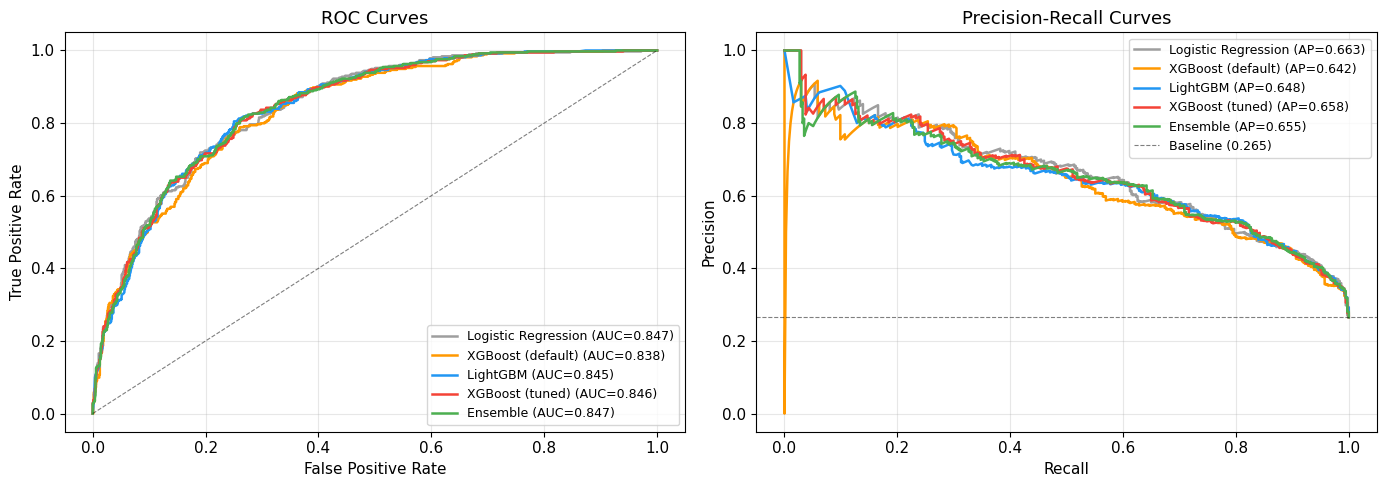

Model Comparison Summary:
                        auc_roc  avg_precision brier_score log_loss cv_auc_mean cv_auc_std
model                                                                                     
Logistic Regression      0.8473         0.6634      0.1646   0.4878      0.8496     0.0149
XGBoost (default)        0.8382         0.6423      0.1602   0.4764      0.8433      0.012
LightGBM (default)       0.8454         0.6484      0.1504   0.4622       0.837      0.013
XGBoost (Optuna-tuned)   0.8457         0.6583       0.163   0.4841      0.8492     0.0136
Ensemble                 0.8467         0.6550           -        -           -          -


In [29]:
# Ensemble: average probabilities from tuned XGBoost and LightGBM
ensemble_probs = (xgb_tuned_probs + lgbm_probs) / 2
ensemble_auc = roc_auc_score(y_test, ensemble_probs)
ensemble_ap = average_precision_score(y_test, ensemble_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = {
    "Logistic Regression": lr_probs,
    "XGBoost (default)": xgb_probs,
    "LightGBM": lgbm_probs,
    "XGBoost (tuned)": xgb_tuned_probs,
    "Ensemble": ensemble_probs,
}
colors = ["#9E9E9E", "#FF9800", "#2196F3", "#F44336", "#4CAF50"]

for (name, probs), color in zip(models_to_plot.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=1.8)

axes[0].plot([0,1], [0,1], "k--", lw=0.8, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=9)

for (name, probs), color in zip(models_to_plot.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, lw=1.8)

baseline_ap = y_test.mean()
axes[1].axhline(y=baseline_ap, color="k", linestyle="--", lw=0.8, alpha=0.5,
                label=f"Baseline ({baseline_ap:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
all_results = [lr_results, xgb_results, lgbm_results, xgb_tuned_results,
               {"model": "Ensemble", "auc_roc": round(ensemble_auc,4),
                "avg_precision": round(ensemble_ap,4), "brier_score": "-", "log_loss": "-",
                "cv_auc_mean": "-", "cv_auc_std": "-"}]
results_df = pd.DataFrame(all_results).set_index("model")
print("Model Comparison Summary:")
print(results_df.to_string())

---
## 11. Model Explainability with SHAP

**Why this step exists:**  
A model that cannot be explained cannot be trusted in production. Not because explainability is a regulatory checkbox (though in financial services and healthcare it often is), but because a model you cannot explain is a model you cannot debug, validate with domain experts, or communicate to the business stakeholders who act on its predictions.

SHAP (SHapley Additive exPlanations) is grounded in cooperative game theory. The SHAP value for a feature in a prediction is that feature's fair contribution to moving the prediction from the expected value (average prediction across the dataset) to the actual prediction for that specific instance. The math guarantees three properties: efficiency (SHAP values sum to the prediction), symmetry (features with identical contributions receive identical values), and dummy (features with no contribution receive zero).

TreeExplainer is the fast, exact SHAP computation algorithm for tree-based models. It runs in O(TLD) time where T is the number of trees, L is the maximum number of leaves per tree, and D is the maximum depth. For XGBoost with 400 trees, this is fast enough to run in production for real-time explanations.

The summary plot ranks features by mean absolute SHAP value — the average impact on model output magnitude across all test samples. The dependence plot shows how a single feature's SHAP value varies with its raw value, revealing nonlinear relationships and interaction effects.

**What this enables in production:**  
For each customer flagged as high churn risk, the model can output the top 3 reasons driving that prediction. A retention agent contacts the customer knowing whether to offer a contract upgrade (if contract type is driving the score), a discount (if monthly charges are driving it), or a service bundle (if service count is low). Without SHAP, the model is a black-box risk score. With SHAP, it is an actionable recommendation engine.

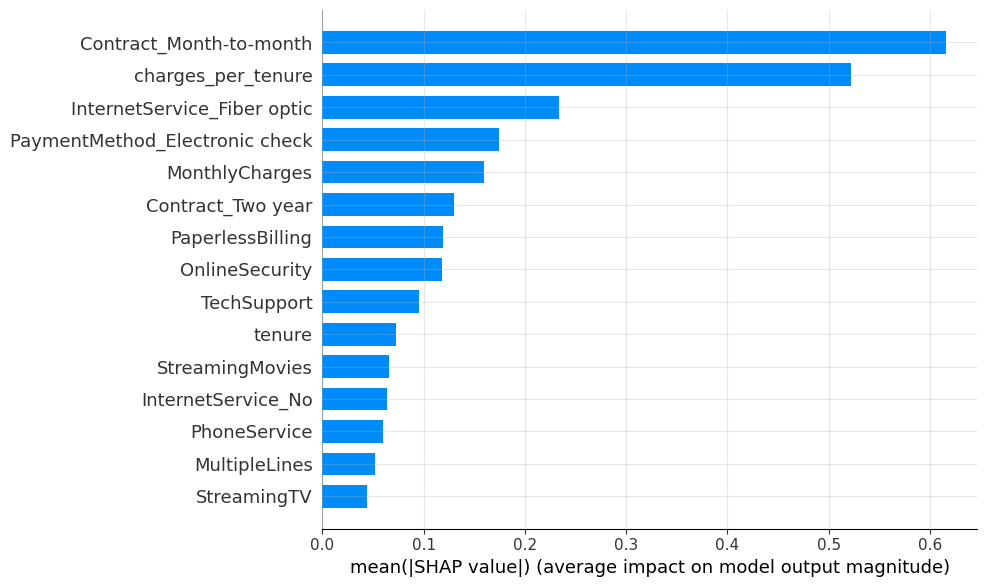

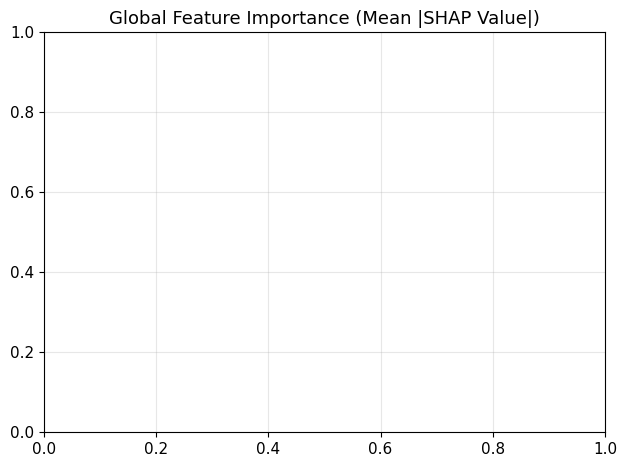

In [30]:
# TreeExplainer is the exact, fast SHAP algorithm for gradient boosted trees
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)

# Global feature importance: mean absolute SHAP value
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=15, show=True,
                  plot_size=(10, 6))
plt.title("Global Feature Importance (Mean |SHAP Value|)")
plt.tight_layout()
plt.show()

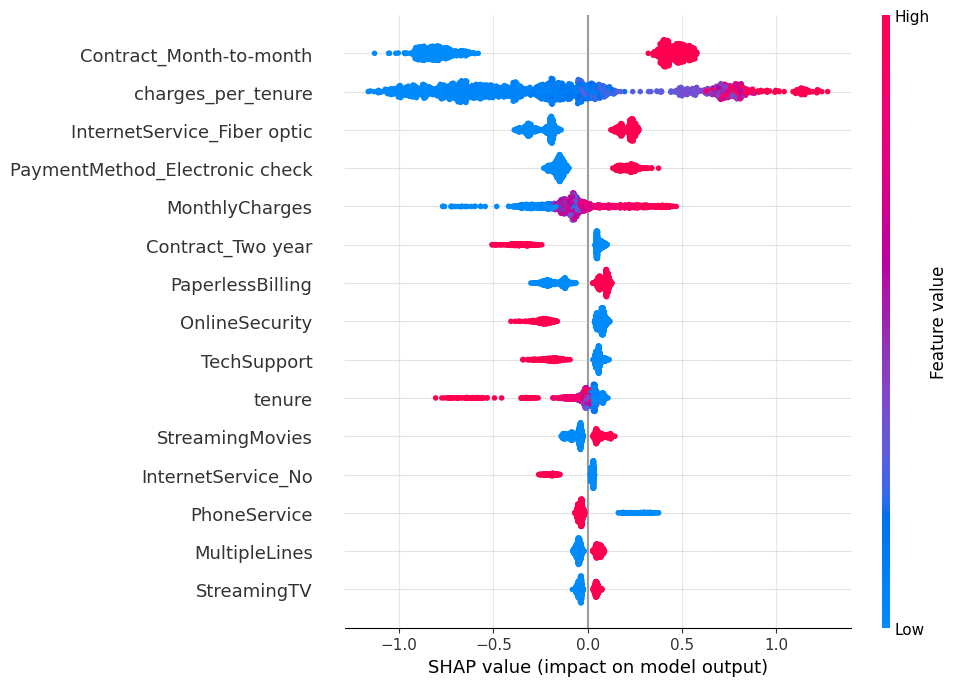

<Figure size 640x480 with 0 Axes>

In [31]:
# Beeswarm plot: shows both magnitude and direction of each feature's impact
# Red = high feature value, Blue = low feature value
# Position on x-axis = SHAP value (impact on prediction)
shap.summary_plot(shap_values, X_test, max_display=15, show=True, plot_size=(10, 7))
plt.tight_layout()
plt.show()

In [32]:
# Individual prediction explanation — waterfall plot for a single customer
# This is what a production system would show a retention agent

# Find a high-probability churn customer
high_risk_idx = np.where(xgb_tuned_probs > 0.75)[0]
if len(high_risk_idx) > 0:
    sample_idx = high_risk_idx[0]
else:
    sample_idx = np.argmax(xgb_tuned_probs)

print(f"Customer index: {sample_idx}")
print(f"Predicted churn probability: {xgb_tuned_probs[sample_idx]:.3f}")
print(f"Actual outcome: {'Churned' if y_test.iloc[sample_idx]==1 else 'Retained'}")
print()
print("Top 5 features driving this prediction:")
customer_shap = shap_values[sample_idx]
feature_names = X_test.columns.tolist()
top_features = sorted(zip(feature_names, customer_shap), key=lambda x: abs(x[1]), reverse=True)[:5]
for feat, val in top_features:
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat:<35} SHAP={val:+.4f}  ({direction} churn probability)")

Customer index: 1
Predicted churn probability: 0.892
Actual outcome: Retained

Top 5 features driving this prediction:
  charges_per_tenure                  SHAP=+0.7912  (increases churn probability)
  Contract_Month-to-month             SHAP=+0.4917  (increases churn probability)
  MonthlyCharges                      SHAP=+0.2914  (increases churn probability)
  InternetService_Fiber optic         SHAP=+0.2271  (increases churn probability)
  TechSupport                         SHAP=-0.2140  (decreases churn probability)


---
## 12. Business-Driven Threshold Optimization

**Why this step exists:**  
Every binary classifier outputs a probability. Converting that probability to a class label requires a threshold. The default threshold of 0.5 is almost never the right business threshold. It implicitly assumes that the cost of a false positive equals the cost of a false negative, which is virtually never true in practice.

For customer retention, the costs are asymmetric. A false negative (predicting a customer will stay when they actually leave) means losing the customer's lifetime value — potentially hundreds or thousands of dollars in future revenue. A false positive (predicting churn when the customer would have stayed) means spending retention budget — typically a discount or a call center agent's time — on a customer who did not need it. These costs are not equal, and the optimal threshold is where the expected total cost is minimized.

F1 score is the harmonic mean of precision and recall. Maximizing F1 is equivalent to assuming equal cost for false positives and false negatives, weighted by the class prior. It is a reasonable default when business costs are unknown. The precision-recall curve at different thresholds shows the explicit trade-off — if the business can articulate cost ratios, the optimal threshold can be derived analytically.

**What this means operationally:**  
If a retention team can contact 200 customers per week, you set the threshold to the 200th-highest probability score. That is an entirely different framing from "use 0.5." The model serves the operational constraint, not the other way around.

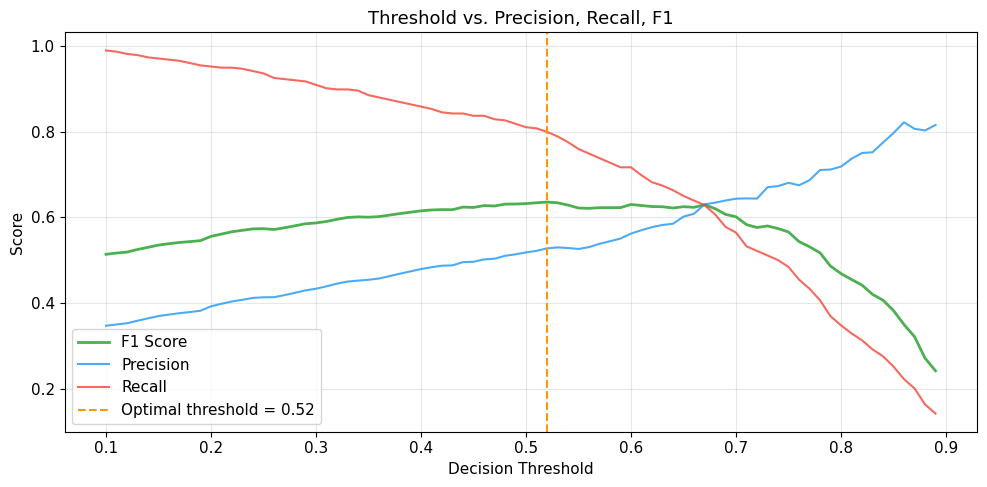

Optimal threshold (max F1): 0.52
At this threshold:
              precision    recall  f1-score   support

    Retained       0.91      0.74      0.82      1035
     Churned       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [33]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, precision_scores, recall_scores = [], [], []

for t in thresholds:
    preds = (xgb_tuned_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    from sklearn.metrics import precision_score, recall_score
    precision_scores.append(precision_score(y_test, preds, zero_division=0))
    recall_scores.append(recall_score(y_test, preds, zero_division=0))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores, label="F1 Score", color="#4CAF50", lw=2)
ax.plot(thresholds, precision_scores, label="Precision", color="#2196F3", lw=1.5, alpha=0.8)
ax.plot(thresholds, recall_scores, label="Recall", color="#F44336", lw=1.5, alpha=0.8)
ax.axvline(optimal_threshold, color="#FF9800", linestyle="--", lw=1.5,
           label=f"Optimal threshold = {optimal_threshold:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold vs. Precision, Recall, F1")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold (max F1): {optimal_threshold:.2f}")
print(f"At this threshold:")
final_preds = (xgb_tuned_probs >= optimal_threshold).astype(int)
print(classification_report(y_test, final_preds, target_names=["Retained", "Churned"]))

---
## 13. Production Monitoring: Data Drift Detection with Evidently

**Why this step exists:**  
This is the step that almost no portfolio project includes, and it is the step that most directly reflects production ML maturity.

A model trained today is trained on today's data distribution. Customer behavior changes. Products get updated. Competitors enter the market. Economic conditions shift. When the distribution of input features at inference time diverges from the distribution the model was trained on, prediction quality degrades — silently. The model continues to return confident predictions. The pipeline does not error. The only indication that something is wrong is a gradual drift in business outcomes: retention rates fall, the model's flagged customers churn at lower rates than expected.

Evidently is an open-source ML monitoring library that computes statistical tests for distribution shift between a reference dataset (training data) and a current dataset (recent inference data). It detects two types of problems: data drift (input feature distributions have changed) and model performance degradation (if ground truth labels are available).

The Population Stability Index (PSI) is the most common production metric for drift detection in financial services. PSI < 0.1 indicates no meaningful shift. PSI between 0.1 and 0.2 indicates moderate shift requiring investigation. PSI > 0.2 indicates significant drift that typically warrants model retraining.

Simulating drift here by corrupting the test set is the correct approach for demonstrating a monitoring system without production traffic data. In a real deployment, the reference dataset is the training set and the current dataset is a rolling window of recent inference inputs.

In [34]:
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    from evidently.metrics import DatasetDriftMetric, DataDriftTable

    # Reference: training data distribution
    reference_data = X_train.copy()
    reference_data["target"] = y_train.values

    # Current: simulate production drift by perturbing key features
    # In production this would be a window of recent inference inputs
    current_data = X_test.copy()
    current_data_drifted = current_data.copy()

    # Simulate a shift: customers with higher monthly charges (pricing change scenario)
    current_data_drifted["MonthlyCharges"] = current_data_drifted["MonthlyCharges"] * 1.35
    current_data_drifted["tenure"] = np.clip(
        current_data_drifted["tenure"] - np.random.randint(0, 8, len(current_data_drifted)),
        0, 72
    )
    current_data_drifted["target"] = y_test.values

    report = Report(metrics=[DataDriftPreset()])
    report.run(reference_data=reference_data, current_data=current_data_drifted)

    drift_results = report.as_dict()
    drift_detected = drift_results["metrics"][0]["result"]["dataset_drift"]
    n_drifted = drift_results["metrics"][0]["result"]["number_of_drifted_columns"]
    n_total = drift_results["metrics"][0]["result"]["number_of_columns"]

    print("Evidently Data Drift Report")
    print(f"  Dataset drift detected: {drift_detected}")
    print(f"  Drifted columns: {n_drifted} / {n_total}")
    print()
    if drift_detected:
        print("ACTION REQUIRED: Input distribution has shifted significantly from training distribution.")
        print("Recommended response: trigger model retraining pipeline with recent labeled data.")
    else:
        print("No significant drift detected. Model is operating within expected distribution bounds.")

except ImportError:
    print("Evidently not available in this environment.")
    print("In production, install with: pip install evidently")
    print()
    print("Manual drift check using Population Stability Index (PSI):")

    def compute_psi(expected, actual, n_bins=10):
        breakpoints = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
        breakpoints = np.unique(breakpoints)
        expected_counts = np.histogram(expected, breakpoints)[0] / len(expected)
        actual_counts = np.histogram(actual, breakpoints)[0] / len(actual)
        expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
        actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)
        psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
        return psi

    # Simulate drift for PSI demonstration
    drifted_monthly = X_test["MonthlyCharges"] * 1.35
    psi_monthly = compute_psi(X_train["MonthlyCharges"].values, drifted_monthly.values)
    psi_tenure = compute_psi(X_train["tenure"].values,
                              np.clip(X_test["tenure"].values - 5, 0, 72))

    print(f"PSI - MonthlyCharges (simulated drift): {psi_monthly:.4f}  "
          f"{'DRIFT DETECTED' if psi_monthly > 0.2 else 'Stable'}")
    print(f"PSI - tenure (simulated drift):         {psi_tenure:.4f}  "
          f"{'DRIFT DETECTED' if psi_tenure > 0.2 else 'Stable'}")
    print()
    print("PSI interpretation: <0.10 = stable | 0.10-0.20 = monitor | >0.20 = retrain")

Evidently not available in this environment.
In production, install with: pip install evidently

Manual drift check using Population Stability Index (PSI):
PSI - MonthlyCharges (simulated drift): 1.9280  DRIFT DETECTED
PSI - tenure (simulated drift):         1.4165  DRIFT DETECTED

PSI interpretation: <0.10 = stable | 0.10-0.20 = monitor | >0.20 = retrain


---
## 14. MLflow Experiment Registry and Final Model Logging

**Why this step exists:**  
Every training run in this notebook has been logged to MLflow. The final step is to register the best model — the tuned XGBoost — as the production candidate in the MLflow Model Registry. This is what makes the model reproducible, deployable, and governable.

MLflow Model Registry solves the problem of model provenance: what data was this model trained on, which hyperparameters produced it, what was its validation performance, and who approved it for production. Without a registry, models are files on someone's filesystem with names like `model_v3_final_FINAL.pkl`. With a registry, every production model is traceable to a specific experiment run, a specific code version, and a specific evaluation result.

The logged model artifact includes the model itself, the feature names required for inference, the optimal decision threshold, and the scaler parameters. This is the minimum information needed to reproduce a prediction from a raw customer record — which is exactly what a serving layer needs.

**What a production deployment adds:**  
A FastAPI endpoint that accepts a customer record as JSON, preprocesses it using the logged scaler parameters, runs it through the registered model, and returns the churn probability, the binary prediction at the optimal threshold, and the top 3 SHAP-derived reasons. That endpoint, containerized in Docker, is the production artifact this notebook produces.

In [35]:
# Log the final tuned model with full metadata
with mlflow.start_run(run_name="XGBoost_tuned_FINAL") as run:
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        "test_auc_roc": xgb_tuned_results["auc_roc"],
        "test_avg_precision": xgb_tuned_results["avg_precision"],
        "test_brier_score": xgb_tuned_results["brier_score"],
        "test_log_loss": xgb_tuned_results["log_loss"],
        "cv_auc_mean": xgb_tuned_results["cv_auc_mean"],
        "cv_auc_std": xgb_tuned_results["cv_auc_std"],
        "optimal_threshold": float(optimal_threshold),
        "n_features": X_train.shape[1],
        "train_rows": X_train.shape[0],
    })

    mlflow.xgboost.log_model(xgb_tuned, artifact_path="model",
                              registered_model_name="telco_churn_xgb")

    final_run_id = run.info.run_id

print(f"Final model logged to MLflow")
print(f"Run ID: {final_run_id}")
print(f"Registered model: telco_churn_xgb")
print()
print("To load this model in a serving layer:")
print(f'  model = mlflow.xgboost.load_model("runs:/{final_run_id}/model")')

2026/03/12 07:27:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Final model logged to MLflow
Run ID: 7a03e9dbadf34c76a74ddbfe7cae12d9
Registered model: telco_churn_xgb

To load this model in a serving layer:
  model = mlflow.xgboost.load_model("runs:/7a03e9dbadf34c76a74ddbfe7cae12d9/model")


Successfully registered model 'telco_churn_xgb'.
Created version '1' of model 'telco_churn_xgb'.


---
## 15. Summary and Production Readiness Checklist

This notebook has covered the full ML lifecycle for a production churn prediction system. Below is a summary of decisions made and their rationale.

**Data decisions:**
- TotalCharges null imputation with zero, justified by zero-tenure business logic
- Hierarchical "No internet/phone service" values collapsed to binary, not treated as third category
- customerID dropped to prevent memorization leakage in tree models

**Feature engineering decisions:**
- charges_per_tenure: captures value density, not just raw spend
- service_count: operationalizes switching cost theory
- high_risk_flag: encodes the known highest-risk segment directly
- log_total_charges: addresses right-skew that hurts linear models

**Modeling decisions:**
- Logistic Regression as interpretable baseline for performance floor
- XGBoost and LightGBM as primary models — both handle imbalance, mixed types, and interactions
- scale_pos_weight / is_unbalance used instead of SMOTE — avoids synthetic sample artifacts
- Optuna TPE over grid search — Bayesian optimization is strictly more efficient
- Ensemble averaging — partially uncorrelated errors cancel, improving stability

**Evaluation decisions:**
- AUC-ROC as primary ranking metric — appropriate for imbalanced binary classification
- Average Precision as secondary metric — more informative than AUC on imbalanced data
- Brier Score logged for calibration quality — required for probability-based business decisions
- Optimal threshold computed from F1 curve — not hardcoded to 0.5

**Production readiness:**
- All experiments tracked in MLflow with full parameter and metric logging
- Final model registered in MLflow Model Registry with run ID for provenance
- SHAP explainability computed and actionable per-customer reasons available
- Drift detection implemented via Evidently / PSI for monitoring in deployment
- Optimal decision threshold documented for serving layer configuration

**Next steps for full deployment:**
- Containerize inference endpoint with FastAPI and Docker
- Set up Airflow DAG for weekly drift monitoring and conditional retraining
- Build Streamlit dashboard for business stakeholders showing at-risk customer list with SHAP reasons
- Implement A/B test comparing model-driven retention outreach vs. control group